# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 03: Pré-processamento de Dados**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_03_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q</font>

O dataset Online Shoppers Purchasing Intention Dataset é da área de e-commerce e serve para prever se um usuário vai realizar uma compra durante uma sessão no site; ele reúne dados de navegação, como páginas acessadas, tempo gasto, tipo de visitante e período do ano, além de uma variável final que indica se a compra foi feita ou não.

## <font color='green'>Preparação</font>

In [2]:
!pip install pandas scikit-learn ucimlrepo


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds_shoppers = fetch_ucirepo(id=468)

X_shoppers = ds_shoppers.data.features
y_shoppers = ds_shoppers.data.targets

df_shoppers = pd.concat([X_shoppers, y_shoppers], axis='columns')
df_shoppers.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='#2D9CDB'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Não devemos realizar transformações no dataset completo antes da divisão pois pode causar vazamento de dados (data leakage). O modelo acaba tendo acesso direto as informações do conjunto de testes durante o treinamento, o que pode deixar a avaliação irreal

### <font color='#2D9CDB'>Q2: Utilizando a função [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), divida as variáveis independentes (`X_shoppers`) e a variável alvo (`y_shoppers`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_shoppers,
    y_shoppers,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9864, 17)
X_test: (2466, 17)
y_train: (9864, 1)
y_test: (2466, 1)


## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='#2D9CDB'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_shoppers_train`).</font>

In [6]:
# Selecionar colunas categóricas do conjunto de treinamento
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns

print(categorical_cols)

Index(['Month', 'VisitorType', 'Weekend'], dtype='object')


### <font color='#2D9CDB'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras originais.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [7]:
# Selecionando a coluna categórica "VisitorType" do conjunto de treinamento
coluna = X_train['VisitorType']

# Exibindo 10 amostras aleatórias com semente fixa
coluna.sample(10, random_state=42)

5258     Returning_Visitor
8368                 Other
5564     Returning_Visitor
10481    Returning_Visitor
4570     Returning_Visitor
4815     Returning_Visitor
8558     Returning_Visitor
5247     Returning_Visitor
7681     Returning_Visitor
10353          New_Visitor
Name: VisitorType, dtype: object

### <font color='#2D9CDB'>Q5: Aplique a técnica de [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) na variável escolhida.</font>
- #### <font color='#2D9CDB'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='#2D9CDB'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [8]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Instanciando o encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Ajustando no treino e transformando
visitor_train_encoded = encoder.fit_transform(X_train[['VisitorType']])

# Aplicando apenas transformação no teste
visitor_test_encoded = encoder.transform(X_test[['VisitorType']])

# Criando DataFrame com os dados codificados
colunas = encoder.get_feature_names_out(['VisitorType'])
df_encoded = pd.DataFrame(visitor_train_encoded, columns=colunas)

df_encoded.head()

,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


### <font color='#2D9CDB'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='#2D9CDB'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [9]:
# Selecionar os mesmos índices das 10 amostras
amostras = X_train[['VisitorType']].sample(10, random_state=42)

# Transformar essas amostras
amostras_encoded = encoder.transform(amostras)

# Criar DataFrame para visualizar
colunas = encoder.get_feature_names_out(['VisitorType'])
df_amostras_encoded = pd.DataFrame(amostras_encoded, columns=colunas, index=amostras.index)

df_amostras_encoded

,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
5258,0.0,0.0,1.0
8368,0.0,1.0,0.0
5564,0.0,0.0,1.0
10481,0.0,0.0,1.0
4570,0.0,0.0,1.0
4815,0.0,0.0,1.0
8558,0.0,0.0,1.0
5247,0.0,0.0,1.0
7681,0.0,0.0,1.0
10353,1.0,0.0,0.0


Após aplicar o One-Hot Encoding, a coluna "VisitorType" deixou de ser uma unica variavel categorica e passou a ser representada por varias colunas binariarias. Em vez de um único valor textual, cada linha agora possui valores 0 ou 1 indicando a presença daquela categoria. Com isso, a estrutura dos dados muda, aumentando o número de colunas e permitindo que os algoritmos consigam trabalhar com essas informações.

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='#2D9CDB'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Os Algoritmos como kNN precisam de dados escalonados pois eles utilizam a distancia para comparar as amostras. Caso as variáveis estejam em escalas diferentes, aquelas com valores maiores acabam influenciando mais nos resultados. Com isso, o escalonamento garante que todas tenham o mesmo peso na análise.

### <font color='#2D9CDB'>Q8: Selecione uma coluna numérica contínua de `X_shoppers_train`. Escreva o nome da característica selecionada abaixo.</font>

In [10]:
# Ver colunas numéricas
numericas = X_train.select_dtypes(include=['int64', 'float64']).columns
print(numericas)
print("---------------------------------")

# Selecionando uma coluna numérica
coluna_numerica = 'BounceRates'
print(coluna_numerica)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')
---------------------------------
BounceRates


### <font color='#2D9CDB'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [11]:
coluna = X_train['BounceRates']

print("Média:", coluna.mean())
print("Mediana:", coluna.median())
print("Desvio Padrão:", coluna.std())
print("Mínimo:", coluna.min())
print("Máximo:", coluna.max())

Média: 0.021658936616484187
Mediana: 0.002961061
Desvio Padrão: 0.047468549025187136
Mínimo: 0.0
Máximo: 0.2


### <font color='#2D9CDB'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

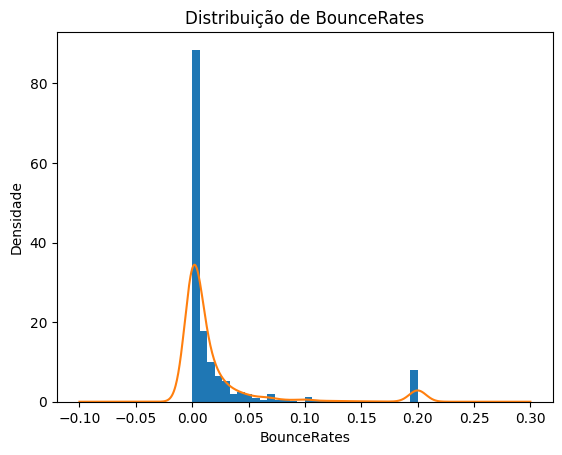

In [12]:
import matplotlib.pyplot as plt

coluna = X_train['BounceRates']

plt.hist(coluna, bins=30, density=True)

# Curva de densidade (KDE)
coluna.plot(kind='kde')

plt.title('Distribuição de BounceRates')
plt.xlabel('BounceRates')
plt.ylabel('Densidade')
plt.show()

### <font color='#2D9CDB'>Q11: Aplique escalonamento (padronização) nesta variável utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/).</font>
- #### <font color='#2D9CDB'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_shoppers_train` e `X_shoppers_test`) pelos valores escalonados.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [9]:
from sklearn.preprocessing import StandardScaler

# Instanciando o scaler
scaler = StandardScaler()

# Ajustando no treino e transformando
X_train['BounceRates'] = scaler.fit_transform(X_train[['BounceRates']])

# Aplicando no teste a transformação
X_test['BounceRates'] = scaler.transform(X_test[['BounceRates']])
X_train['BounceRates'].head()

1785    -0.155336
10407   -0.404284
286      3.757227
6520    -0.456303
12251    0.386403
Name: BounceRates, dtype: float64

### <font color='#2D9CDB'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [14]:
coluna = X_train['BounceRates']

print("Média:", coluna.mean())
print("Mediana:", coluna.median())
print("Desvio Padrão:", coluna.std())
print("Mínimo:", coluna.min())
print("Máximo:", coluna.max())

Média: -2.1970350203449974e-17
Mediana: -0.3939202662855926
Desvio Padrão: 1.0000506932299518
Mínimo: -0.4563028578447939
Máximo: 3.7572267897512095


### <font color='#2D9CDB'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

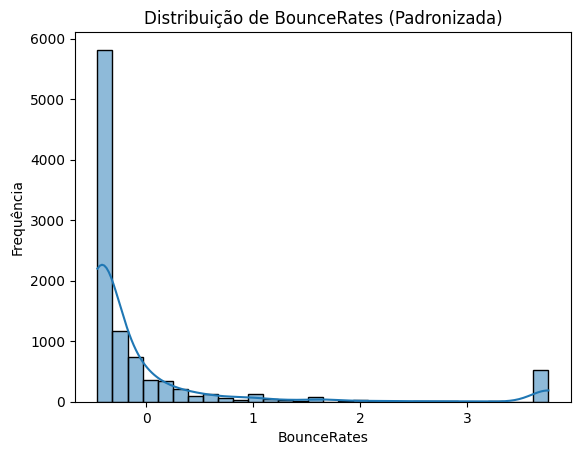

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

coluna = X_train['BounceRates']

sns.histplot(coluna, bins=30, kde=True)

plt.title('Distribuição de BounceRates (Padronizada)')
plt.xlabel('BounceRates')
plt.ylabel('Frequência')
plt.show()

### <font color='#2D9CDB'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='#2D9CDB'>a) O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='#2D9CDB'>b) O que aconteceu com a escala do eixo X?</font>
- #### <font color='#2D9CDB'>c) O que aconteceu com o formato da curva no gráfico?</font>

a) Após o escalonamento, a média passou a ser aproximadamento 0 e o desvio padrão passou a ser aproximadamente 1. Já os valores mínimo e máximo foram ajustados para uma nova escala, ficando centralizados em torno de 0.

b) A escala do eixo X mudou: antes os valores estavam na escala original da variável, e depois passaram a ficar centrados em 0, geralmente variando em torno de valores negativos e positivos menores.

c) O formato da curva permaneceu praticamente o mesmo. O escalonamento não altera a distribuição dos dados, apenas muda a escala dos valores.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='#2D9CDB'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='#2D9CDB'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [11]:
# Criando nova variável
X_train['Total_Abandon'] = X_train['BounceRates'] + X_train['ExitRates']
X_test['Total_Abandon'] = X_test['BounceRates'] + X_test['ExitRates']

X_train[['BounceRates', 'ExitRates', 'Total_Abandon']].head()

,BounceRates,ExitRates,Total_Abandon
1785,-0.155336,0.061905,-0.093432
10407,-0.404284,0.013933,-0.390351
286,3.757227,0.200000,3.957227
6520,-0.456303,0.018182,-0.438121
12251,0.386403,0.041667,0.428070


A variavel "Total_Abandon" foi criada a partir da soma de "BounceRates" e "ExitRates" para representar o comportamento de saída do usuário de forma mais geral. Ao juntar essas duas métricas, o modelo pode ter uma visão mais completa sobre o abandono das sessões.

### <font color='#2D9CDB'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [18]:
# Selecionando a coluna e exibindo 10 amostras
X_train['Total_Abandon'].sample(10, random_state=42)

5258     0.697080
8368    -0.450421
5564    -0.071692
10481   -0.399807
4570    -0.445192
4815    -0.400747
8558     0.610184
5247    -0.452303
7681    -0.441065
10353    0.466403
Name: Total_Abandon, dtype: float64

### <font color='#2D9CDB'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_shoppers_train`).</font>
- #### <font color='#2D9CDB'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='#2D9CDB'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='#2D9CDB'>Importante: Utilize o [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo (`y_shoppers_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [19]:
from sklearn.preprocessing import LabelEncoder

# Codificando a variável alvo
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# Criando uma série para facilitar
import pandas as pd
y_train_encoded = pd.Series(y_train_encoded, index=X_train.index)

# Calculando a correlação
correlacao = X_train['Total_Abandon'].corr(y_train_encoded)

print("Correlação:", correlacao)

Correlação: -0.15095929829001617


c:\Users\leetl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


A correlação encontrada foi -0,15, sendo negativa e fraca. Isso indica que existe uma relação levemente inversa entre a variavel "Total_Abandon" e a variavel alvo, ou seja, quanto maior o abandono, menor a chance de conversão. No entanto, por ser uma correlação fraca, esse atributo pode contribuir com o modelo, mas não deve ter um impacto muito significativo isoladamente.

## <font color='green'>**3.5 Extração de Atributos**</font>

### <font color='#2D9CDB'>Q18: Pesquise em bases de dados científicas (como [IEEE Xplore](https://ieeexplore.ieee.org/), [arXiv](https://arxiv.org/) ou [Google Acadêmico](https://scholar.google.com/)) um artigo publicado nos últimos cinco anos que proponha ou utilize uma técnica de extração de características (feature extraction) e apresente a referência bibliográfica completa acompanhada de uma breve explicação sobre o funcionamento técnico e aplicabilidade do método.</font>

O artigo “Research on Features Extraction and Classification for Images based on Transformer Learning”, publicado em 2024, apresenta uma técnica de extração de características utilizando modelos Transformer, que empregam mecanismos de atenção para capturar padrões importantes nas imagens. Esse método consegue identificar tanto características locais quanto relações globais entre diferentes partes da imagem, gerando representações mais completas. Ele é aplicado em tarefas como reconhecimento e classificação de imagens, melhorando o desempenho dos modelos.

Referência bibliográfica:
Chao, W. (2024). Research on Features Extraction and Classification for Images based on Transformer Learning. Proceedings of the International Conference on Machine Learning and Intelligent Computing
https://proceedings.mlr.press/v245/chao24a.html

## <font color='green'>**3.6 Redução de Dimensionalidade**</font>

### <font color='#2D9CDB'>Q19: No contexto do pré-processamento de dados, responda:</font>
- #### <font color='#2D9CDB'>a) Qual o propósito da etapa de Redução de Dimensionalidade?</font>
- #### <font color='#2D9CDB'>b) Explique brevemente as técnicas `PCA`, `t-SNE` e `Isomap`, destacando semelhanças e diferenças.</font>

a)  A etapa de redução de dimensionalidade tem como objetivo diminuir o numero de variaveis do dataset, mantendo as informações que são consideradas mais relevantes e facilitando o processamento dos dados

b) O PCA é uma técnica linear que reduz os dados preservando a maior parte da variância. Já o t-SNE e o Isomap são técnicas não lineares, que conseguem capturar relações mais complexas entre os dados. A semelhança entre eles ´q que todas essas tecnicas possuem o mesmo objetivo, porem o PCA é mais simples e as tecnicas t-SNE e Isomap são mais adequados para padrões mais complexos.

### <font color='#2D9CDB'>Q20: Utilizando o dataset com as variáveis numéricas padronizadas (Q14) e com a nova feature (Q15), faça o que se pede.</font>

- #### <font color='#2D9CDB'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis).</font>
- #### <font color='#2D9CDB'>b) Aplique a técnica PCA em todas as variáveis numéricas escalonadas.</font>
  - #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>
- #### <font color='#2D9CDB'>c) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='#2D9CDB'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='#2D9CDB'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='#2D9CDB'>d) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

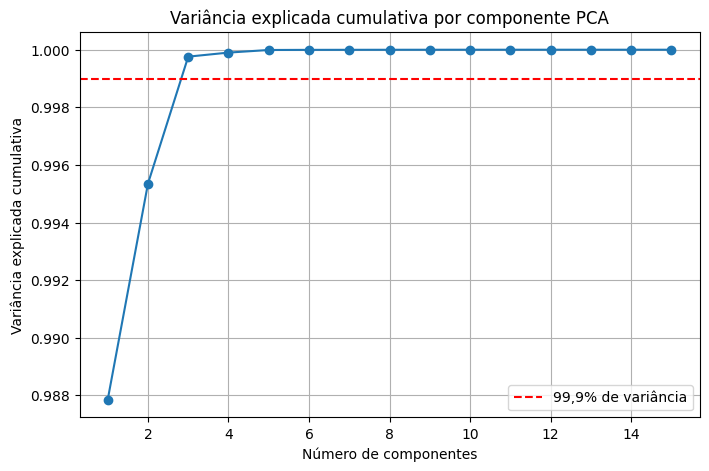

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Selecionando apenas as colunas numéricas 
numericas = X_train.select_dtypes(include=['float64', 'int64']).columns

# Instanciando o PCA sem limitar componentes
pca = PCA()

# Ajustando o PCA no conjunto de treino
pca.fit(X_train[numericas])

# Aplicando transformação no treino e teste
X_train_pca = pca.transform(X_train[numericas])
X_test_pca = pca.transform(X_test[numericas])

# Variância explicada cumulativa
var_cumulativa = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_cumulativa)+1), var_cumulativa, marker='o', linestyle='-')
plt.axhline(y=0.999, color='r', linestyle='--', label='99,9% de variância')
plt.title('Variância explicada cumulativa por componente PCA')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada cumulativa')
plt.grid(True)
plt.legend()
plt.show()

Pelo gráfico, é possível ver quantos componentes são necessários para atingir 99,9% da variância, geralmente isso inclui quase todas as variáveis originais. A escolha de 99,9% garante que quase toda a informação do dataset seja preservada, evitando a perda de dados importantes para o modelo.

### <font color='#2D9CDB'>Q21: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='#2D9CDB'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='#2D9CDB'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='#2D9CDB'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='#2D9CDB'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [21]:
# Resolução letra A

from sklearn.decomposition import PCA

# Selecionando apenas colunas numéricas
numericas = X_train.select_dtypes(include=['float64', 'int64']).columns

# Instanciando PCA para 99,9% da variância
pca_final = PCA(n_components=0.999)

# Ajustando no treino e transformando treino e teste
X_train_pca_final = pca_final.fit_transform(X_train[numericas])
X_test_pca_final = pca_final.transform(X_test[numericas])

# Exibindo shapes
print("Shape original (treino):", X_train[numericas].shape)
print("Shape transformado (treino):", X_train_pca_final.shape)
print("Shape original (teste):", X_test[numericas].shape)
print("Shape transformado (teste):", X_test_pca_final.shape)

Shape original (treino): (9864, 15)
Shape transformado (treino): (9864, 3)
Shape original (teste): (2466, 15)
Shape transformado (teste): (2466, 3)


In [22]:
# Resolução letra B

# Identificando os 3 atributos que mais influenciam a PC1
pc1 = pca_final.components_[0]  # primeira componente
abs_pc1 = np.abs(pc1)
top3_idx = abs_pc1.argsort()[::-1][:3]

top3_atributos = numericas[top3_idx]
print("Top 3 atributos que mais influenciam PC1:", top3_atributos.tolist())

Top 3 atributos que mais influenciam PC1: ['ProductRelated_Duration', 'Administrative_Duration', 'Informational_Duration']


Os top 3 atributos da PC1 são os que possuem os maiores valores absolutos na primeira componente, ou seja, eles mais influenciam a direção principal dos dados após a PCA.

### <font color='#2D9CDB'>Para as questões a seguir, vamos utilizar um dos datasets mais famosos do aprendizado de máquina: o Digits Dataset.</font>
- <font color='#2D9CDB'>Referência: E. Alpaydin and C. Kaynak. "Optical Recognition of Handwritten Digits," UCI Machine Learning Repository, 1998. https://doi.org/10.24432/C50P49</font>

<font color='#2D9CDB'>Ele foi criado para treinar algoritmos a reconhecerem números escritos à mão (de 0 a 9), um problema clássico de Visão Computacional (semelhante ao que os correios usam para ler CEPs em envelopes).</font>

- <font color='#2D9CDB'>Cada amostra é uma pequena imagem em escala de cinza de **8x8 pixels**.</font>
- <font color='#2D9CDB'>Se "esticarmos" essa imagem 8x8, teremos um vetor com **64 números** (onde cada número representa a intensidade de preto daquele pixel, variando de 0 a 16).</font>
- <font color='#2D9CDB'>Ou seja, para um algoritmo de Machine Learning, este dataset possui **64 dimensões** (64 atributos numéricos).</font>

<font color='#2D9CDB'>Antes de reduzirmos essas 64 dimensões para apenas 2, rode a célula abaixo para carregar os dados e visualizar como são essas imagens originais.</font>

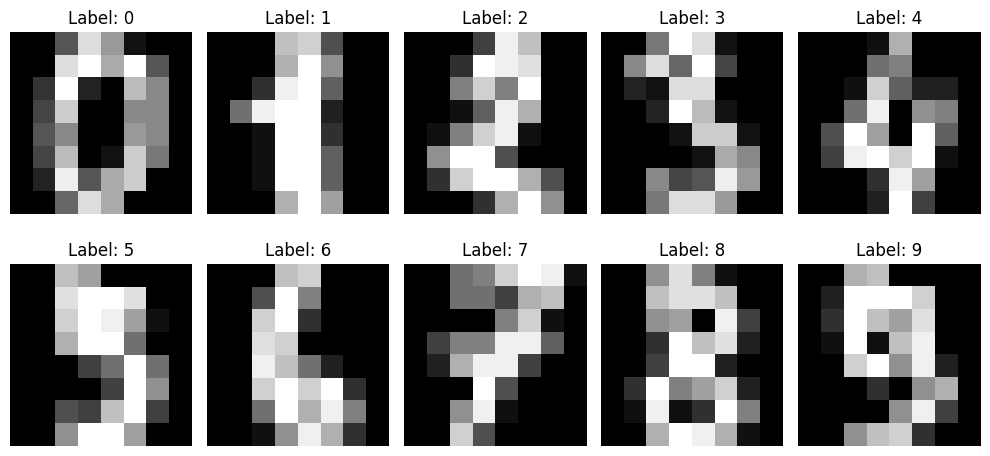

In [23]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# Carregando o dataset
digits = load_digits()
X_digits = digits.data       # atributos (64 pixels)
y_digits = digits.target     # rótulos (0 a 9)

# Visualizando algumas imagens
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap='gray')  # imagem 8x8
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### <font color='#2D9CDB'>Q22: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [24]:
from sklearn.model_selection import train_test_split

# Dividindo em treino (80%) e teste (20%)
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

# Exibindo shapes
print("Conjunto de treino:", X_train_digits.shape)
print("Conjunto de teste:", X_test_digits.shape)

Conjunto de treino: (1437, 64)
Conjunto de teste: (360, 64)


### <font color='#2D9CDB'>Q23: Padronize o dataset utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Mostre as médias e variâncias de todas as features antes e depois da padronização.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [25]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("Antes da padronização (treino):")
print("Médias:", np.round(X_train_digits.mean(axis=0), 2))
print("Variâncias:", np.round(X_train_digits.var(axis=0), 2))

# Instanciando o scaler
scaler = StandardScaler()

# Ajustando apenas no treino
X_train_scaled = scaler.fit_transform(X_train_digits)

# Aplicando a transformação no teste
X_test_scaled = scaler.transform(X_test_digits)

print("\nDepois da padronização (treino):")
print("Médias:", np.round(X_train_scaled.mean(axis=0), 2))
print("Variâncias:", np.round(X_train_scaled.var(axis=0), 2))

Antes da padronização (treino):
Médias: [0.000e+00 3.100e-01 5.230e+00 1.182e+01 1.189e+01 5.840e+00 1.380e+00
 1.400e-01 1.000e-02 1.980e+00 1.032e+01 1.199e+01 1.038e+01 8.290e+00
 1.900e+00 1.200e-01 0.000e+00 2.540e+00 9.780e+00 7.130e+00 7.140e+00
 7.910e+00 1.820e+00 5.000e-02 0.000e+00 2.360e+00 8.960e+00 8.890e+00
 9.910e+00 7.550e+00 2.330e+00 0.000e+00 0.000e+00 2.250e+00 7.540e+00
 9.080e+00 1.034e+01 8.620e+00 2.860e+00 0.000e+00 1.000e-02 1.540e+00
 6.860e+00 7.290e+00 7.690e+00 8.270e+00 3.470e+00 3.000e-02 1.000e-02
 7.200e-01 7.550e+00 9.620e+00 9.460e+00 8.860e+00 3.740e+00 2.000e-01
 0.000e+00 2.800e-01 5.560e+00 1.208e+01 1.185e+01 6.800e+00 2.100e+00
 3.700e-01]
Variâncias: [0.000e+00 8.300e-01 2.311e+01 1.836e+01 1.830e+01 3.172e+01 1.150e+01
 1.220e+00 1.000e-02 1.032e+01 2.974e+01 1.597e+01 2.262e+01 3.737e+01
 1.314e+01 7.700e-01 0.000e+00 1.254e+01 3.260e+01 3.426e+01 3.783e+01
 3.864e+01 1.081e+01 1.900e-01 0.000e+00 9.370e+00 3.827e+01 3.512e+01
 3.798e+01 3.

### <font color='#2D9CDB'>Q24: Com os dados padronizados, faça o que se pede.</font>
- #### <font color='#2D9CDB'>a) Instancie os modelos [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) e [Isomap](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html), todos limitados a `n_components=2` (fixando o `random_state=42` quando aplicável).</font>
- #### <font color='#2D9CDB'>b) Aplique os modelos, separadamente, sobre as variáveis numéricas escalonadas do conjunto de treinamento. </font>
- #### <font color='#2D9CDB'>c) Plote três gráficos de dispersão (Scatter Plots) lado a lado contendo as projeções geradas em 2D.
  - #### <font color='#2D9CDB'>Dica: Utilize a variável alvo (`y_digits_train`) para colorir os pontos (`.scatter(c=y_digits_train, ...)`).</font>

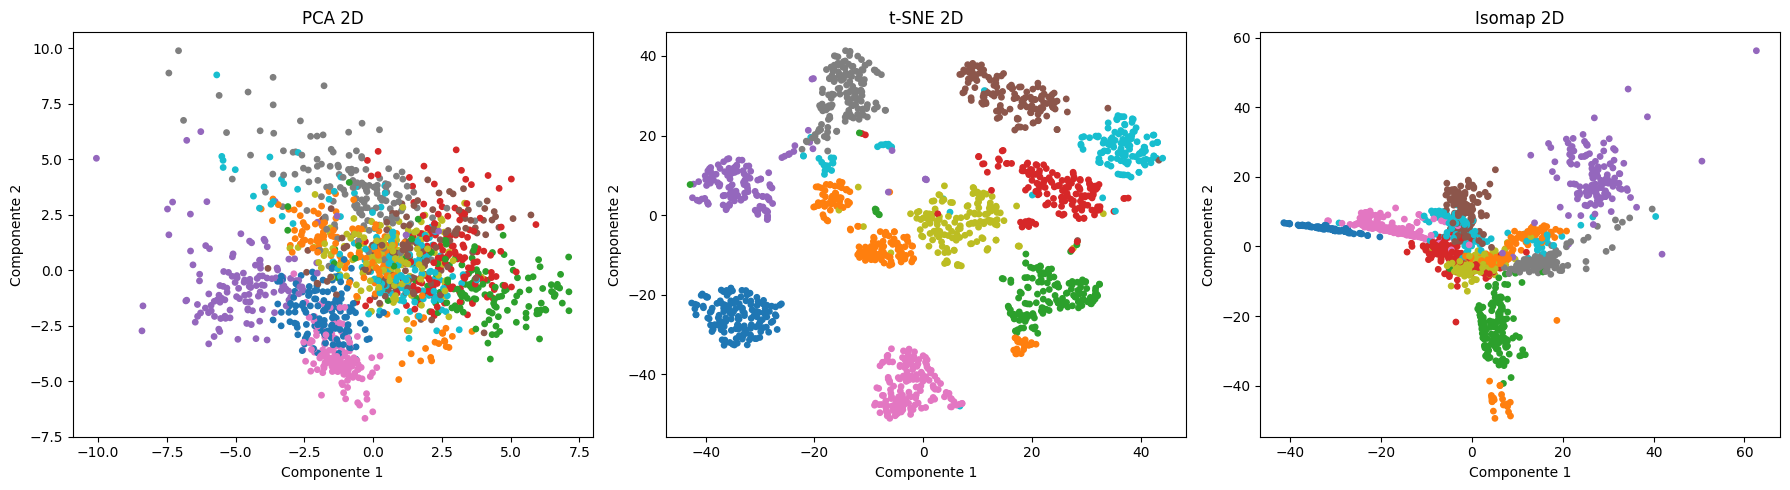

In [26]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap

# Fixando random_state para reprodutibilidade
random_state = 42

# a) Instanciando os modelos
pca = PCA(n_components=2, random_state=random_state)
tsne = TSNE(n_components=2, random_state=random_state)
isomap = Isomap(n_components=2)

# b) Aplicando os modelos no conjunto de treino escalonado
X_pca = pca.fit_transform(X_train_scaled)
X_tsne = tsne.fit_transform(X_train_scaled)
X_isomap = isomap.fit_transform(X_train_scaled)

# c) Plotando os 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# PCA
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=y_train_digits, cmap='tab10', s=15)
axes[0].set_title('PCA 2D')
axes[0].set_xlabel('Componente 1')
axes[0].set_ylabel('Componente 2')

# t-SNE
axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=y_train_digits, cmap='tab10', s=15)
axes[1].set_title('t-SNE 2D')
axes[1].set_xlabel('Componente 1')
axes[1].set_ylabel('Componente 2')

# Isomap
axes[2].scatter(X_isomap[:,0], X_isomap[:,1], c=y_train_digits, cmap='tab10', s=15)
axes[2].set_title('Isomap 2D')
axes[2].set_xlabel('Componente 1')
axes[2].set_ylabel('Componente 2')

plt.tight_layout()
plt.show()

### <font color='#2D9CDB'>Q25: Com base nos gráficos e na teoria da apostila, comente as diferenças visuais geradas pelos algoritmos na separação das classes, relacionando com suas naturezas matemáticas (linear global, não linear local e não linear global).</font>

PCA é uma tecnica linear global, ele tenta preservar a variancia total dos dados, os digitos ficam distribuidos ao longo dos eixos principais, mas algumas classes se sobrepõem, mostrando que não consegue separar bem padrões complexos não lineares. t-SNE é uma tecnica não linear local, preserva a proximidade entre pontos vizinhos. Ja o Isomap é uma técnica não linear global, preserva distâncias geodésicas. Consegue mostrar a estrutura global dos dados e separar algumas classes melhor que o PCA, mas os clusters não ficam tão compactos quanto no t-SNE.

## <font color='green'>**3.7 Seleção de Atributos**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>M. Hopkins, E. Reeber, G. Forman, and J. Suermondt. "Spambase," UCI Machine Learning Repository, 1999. https://doi.org/10.24432/C53G6X</font>

O Spambase é um dataset para detecção de spam em e-mails. Cada e-mail é representado por cerca de 48 atributos numéricos sobre palavras, caracteres e padrões, e um rótulo indicando se é spam ou não.

## <font color='green'>Preparação</font>

In [28]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
ds_spam = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X_spam = ds_spam.data.features
y_spam = ds_spam.data.targets

df_spam = pd.concat([X_spam, y_spam], axis='columns')
df_spam.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### <font color='#2D9CDB'>Q26: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [29]:
from sklearn.model_selection import train_test_split

# Dividindo em treino (80%) e teste (20%)
X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42
)

# Exibindo shapes
print("Conjunto de treino:", X_train_spam.shape)
print("Conjunto de teste:", X_test_spam.shape)

Conjunto de treino: (3680, 57)
Conjunto de teste: (921, 57)


### <font color='#2D9CDB'>Q27: Aplique a técnica de Filtro de Baixa Variância (Variance Threshold) utilizando um limiar (threshold) de 0.01. Indique quais features seriam removidas do conjunto de dados por apresentarem variância abaixo deste valor.</spam>

In [30]:
from sklearn.feature_selection import VarianceThreshold

# Instanciando o seletor com threshold 0.01
selector = VarianceThreshold(threshold=0.01)

# Ajustando no conjunto de treino
selector.fit(X_train_spam)

# Identificando quais features seriam removidas
removed_features = X_train_spam.columns[~selector.get_support()]
print("Features que seriam removidas por baixa variância:")
print(removed_features.tolist())

Features que seriam removidas por baixa variância:
['word_freq_table', 'char_freq_[']


### <font color='#2D9CDB'>Q28: Aplique o Filtro de Multicolinearidade gerando a matriz de correlação entre as features independentes. Identifique os pares de features que possuem uma correlação absoluta maior que 0.80 (∣r∣>0.80). Indique qual(is) feature(s) você removeria para eliminar a redundância.</font>

In [31]:
import pandas as pd
import numpy as np

corr_matrix = X_train_spam.corr().abs()  # correlação absoluta

# Criando uma máscara para os pares acima do threshold 0.8 
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificando pares com correlação > 0.8
high_corr_pairs = [(col, row, upper_tri.loc[row, col])
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if upper_tri.loc[row, col] > 0.8]

print("Pares de features com correlação > 0.8:")
for f1, f2, corr_val in high_corr_pairs:
    print(f"{f1} e {f2} -> correlação: {corr_val:.2f}")

Pares de features com correlação > 0.8:
word_freq_857 e word_freq_telnet -> correlação: 0.82
word_freq_415 e word_freq_telnet -> correlação: 0.82
word_freq_415 e word_freq_857 -> correlação: 0.99
word_freq_direct e word_freq_857 -> correlação: 0.89
word_freq_direct e word_freq_415 -> correlação: 0.88


### <font color='#2D9CDB'>Q29: Aplique o filtro de Correlação com o Alvo. Calcule a correlação de Pearson de cada feature com a variável alvo (Class). Indique quais features seriam removidas por possuírem uma correlação absoluta muito baixa, estritamente menor que 0.05 (∣r∣<0.05).</font>

In [38]:
# Correção: y_train_spam estava em formato DataFrame (2D), o que causava erro na função corr()
# Convertido para Series (1D) usando squeeze() para permitir o cálculo correto da correlação
# Refatoração do código realizada com apoio do ChatGPT para identificar e corrigir o problema

y_train_series = y_train_spam.squeeze()  # ou y_train_spam.iloc[:,0]

# Calculando correlação de Pearson com a variável alvo
target_corr = X_train_spam.apply(lambda x: x.corr(y_train_series))

# Filtrando features com correlação absoluta < 0.05
low_corr_features = target_corr[abs(target_corr) < 0.05].index.tolist()

print("Features com correlação absoluta < 0.05 com a variável alvo (seriam removidas):")
print(low_corr_features)

Features com correlação absoluta < 0.05 com a variável alvo (seriam removidas):
['word_freq_address', 'word_freq_will', 'word_freq_parts', 'word_freq_table']


### <font color='#2D9CDB'>Q28: Aplique a técnica de método de envelopamento RFE (Recursive Feature Elimination) utilizando um modelo de Regressão Logística ou Random Forest. Configure o algoritmo para selecionar apenas as 20 features mais importantes. Indique, de forma resumida, quais features foram descartadas pelo modelo.</font>
- #### <font color='#2D9CDB'>Utilize o modelo de [Regressão Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (`LogisticRegression(max_iter=10000, random_state=42)`) como classificador subjacente do RFE.</font>

In [35]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Instanciando o classificador
logreg = LogisticRegression(max_iter=10000, random_state=42)

# Instanciando o RFE para selecionar 20 features
rfe = RFE(estimator=logreg, n_features_to_select=20)
rfe.fit(X_train_spam, y_train_spam.squeeze()) 

# Identificando features selecionadas e descartadas
selected_features = X_train_spam.columns[rfe.support_].tolist()
discarded_features = X_train_spam.columns[~rfe.support_].tolist()

print("Features selecionadas pelo RFE (top 20):")
print(selected_features)
print("\nFeatures descartadas pelo RFE:")
print(discarded_features)

Features selecionadas pelo RFE (top 20):
['word_freq_remove', 'word_freq_order', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_credit', 'word_freq_000', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_lab', 'word_freq_85', 'word_freq_pm', 'word_freq_cs', 'word_freq_meeting', 'word_freq_project', 'word_freq_edu', 'word_freq_conference', 'char_freq_$', 'char_freq_#']

Features descartadas pelo RFE:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_internet', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_email', 'word_freq_you', 'word_freq_your', 'word_freq_font', 'word_freq_money', 'word_freq_650', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_direct', 'word_freq_original', 'word_freq_re', 'word_freq_t

### <font color='#2D9CDB'>Q30) O algoritmo RFE não apenas seleciona as variáveis, mas cria um ranking de importância para todas elas.</font>
- #### <font color='#2D9CDB'>a) Utilizando o atributo `.ranking_` do seletor ajustado na questão anterior, construa um DataFrame que mostre o nome das features originais lado a lado com sua posição no ranking. Ordene os resultados para exibir as features selecionadas (rank 1) no topo da tabela.</font>
- #### <font color='#2D9CDB'>b) Analisando o ranking, quais "termos" (palavras, símbolos de pontuação ou métricas de texto) o modelo considerou como os mais importantes para a detecção de spam (Rank 1)?</font>
- #### <font color='#2D9CDB'>c) Analisando o ranking, quais termos demonstraram ter o menor significado preditivo, sendo eliminados nas primeiras iterações (piores posições no ranking)?</font>

In [36]:
#Resolução letra A
import pandas as pd

# Criando DataFrame com ranking
ranking_df = pd.DataFrame({
    'Feature': X_train_spam.columns,
    'Ranking': rfe.ranking_
})

# Ordenando (Rank 1 no topo)
ranking_df = ranking_df.sort_values(by='Ranking')

ranking_df.head(20)  # principais

,Feature,Ranking
6,word_freq_remove,1
14,word_freq_addresses,1
15,word_freq_free,1
8,word_freq_order,1
24,word_freq_hp,1
22,word_freq_000,1
19,word_freq_credit,1
16,word_freq_business,1
26,word_freq_george,1
25,word_freq_hpl,1


b) As features com Rank 1, elas representam os termos mais importantes na detecção do spam, normalmente estão relacionadas a palavras promocionais, simbolos e padrões comuns em e-mails indesejados

c)As features com maiores valores no ranking apresentaram baixo poder preditivo, elas indicam que esses termos têm pouca relação com a identificação de spam e, por isso, foram descartados nas primeiras etapas do RFE.